In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
df = pd.read_csv('/content/drive/MyDrive/AI/week5/abalone.csv')

df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


기존 코드로 진행시 accuracy가 낮음

->드롭아웃층에서 적은 데이터중 30%를 날리는것 또한 영향을 준다 생각하여 10%로 줄임

->layer 은닉층을 4개로 더 늘리고 뉴런을 16, 32, 64, 128 등으로 설정
epoch 값을 늘리고 batch_size 값을 16,32 등 바꿔 보았지만
epoch 값을 늘릴수록 모델 accuracy는 90인 반면 test accuracy는 60으로 과적합되고 batch_size값을 바꿔도 마찬가지임

=> 모델부분에서 학습하여도 Rings를 3개로 나눴을때 평균적으로 60, 2개로 나눴을때 평균적으로 79를 못넘김



중앙값에 따라 분류할 시 test accuracy가 일정 값(2개 클래스-0.79, 3개 클래스-0.60)이상 올라가지 않음
상위/하위 구간으로 2진 분류(중간값 제거)시 0.89까지 올라가는것을 확인 가능

이진 인코딩

In [32]:
# Rings를 2개 클래스로 나누기
#threshold = int(df['Rings'].median())
#df['Rings_class'] = (df['Rings'] > threshold).astype(int)

In [33]:
# Rings를 하위/상위 구간 기준으로 2분류
low_th = df['Rings'].quantile(0.30)
high_th = df['Rings'].quantile(0.70)

df2 = df[(df['Rings'] <= low_th) | (df['Rings'] >= high_th)].copy()
df2['Rings_class'] = (df2['Rings'] >= high_th).astype(int)

print("하위 기준값:", low_th)
print("상위 기준값:", high_th)
print(df2['Rings_class'].value_counts())

하위 기준값: 8.0
상위 기준값: 11.0
Rings_class
1    1447
0    1407
Name: count, dtype: int64


In [34]:
# 입력(X), 정답(y) 분리
X = df2.drop(['Rings', 'Rings_class'], axis=1)
y = df2['Rings_class'].astype(int)

In [35]:
# 성별(Sex)만 원-핫 인코딩
X = pd.get_dummies(X, columns=['Sex'], drop_first=False)

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0,stratify=y)

In [37]:
# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

원 핫 인코딩

In [38]:
# y를 원-핫 인코딩
y_train = pd.get_dummies(y_train).values
y_test = pd.get_dummies(y_test).values

In [39]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2283, 11), (2283, 2), (571, 11), (571, 2))

In [40]:
# Sequential 방식으로 딥러닝 분류 모델 생성
model = models.Sequential([
    # 입력층 + 첫 번째 은닉층
    # 뉴런 128개, 활성화 함수는 ReLU
    # input_shape=(X.shape[1],) 는 입력 특성 개수를 의미
    layers.Dense(128, activation="relu", input_shape=(X.shape[1],)),

    # 드롭아웃 층
    # 학습 중 10%의 뉴런을 무작위로 비활성화하여 과적합 방지
    # 데이터가 많이 없음으로 30% 드롭은 성능저하에 영향이 간다 생각하여 10%로 변경
    layers.Dropout(0.1),

    # 두 번째 은닉층
    # 뉴런 64개, 활성화 함수는 ReLU
    layers.Dense(64, activation="relu"),

    # 세 번째 은닉층
    # 뉴런 32개, 활성화 함수는 ReLU
    layers.Dense(32, activation="relu"),

    # 네 번째 은닉층
    # 뉴런 16개, 활성화 함수는 ReLU
    layers.Dense(16, activation="relu"),

    # 출력층
    # softmax를 사용하여 각 클래스에 대한 확률 출력
    layers.Dense(2, activation="softmax")
])

# 모델 학습 방식 설정
model.compile(
    optimizer="adam",                  # 가중치 최적화 방법
    loss="categorical_crossentropy",   # 원-핫 인코딩된 다중분류용 손실 함수
    metrics=["accuracy"]               # 성능 평가 지표로 정확도 사용
)

# 모델 학습
history = model.fit(
    X_train, y_train,          # 학습 데이터
    validation_split=0.2,      # 학습 데이터의 20%를 검증용으로 사용
    epochs=50,                 # 전체 데이터를 50번 반복 학습
    batch_size=16,             # 한 번에 16개씩 묶어서 학습
    verbose=1                  # 학습 과정을 출력
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8160 - loss: 0.4046 - val_accuracy: 0.8796 - val_loss: 0.3115
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8521 - loss: 0.3325 - val_accuracy: 0.8862 - val_loss: 0.2773
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8773 - loss: 0.2987 - val_accuracy: 0.8775 - val_loss: 0.2857
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8768 - loss: 0.2915 - val_accuracy: 0.8906 - val_loss: 0.2580
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8877 - loss: 0.2823 - val_accuracy: 0.8862 - val_loss: 0.2555
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8910 - loss: 0.2735 - val_accuracy: 0.8972 - val_loss: 0.2604
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8899 - loss: 0.2696 - val_accuracy: 0.8993 - val_loss: 0.2685
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8899 - loss: 0.2730 - val_accuracy: 0.9037 - val_

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


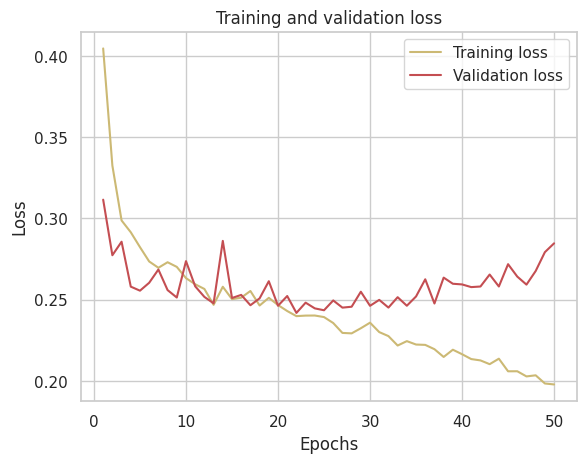

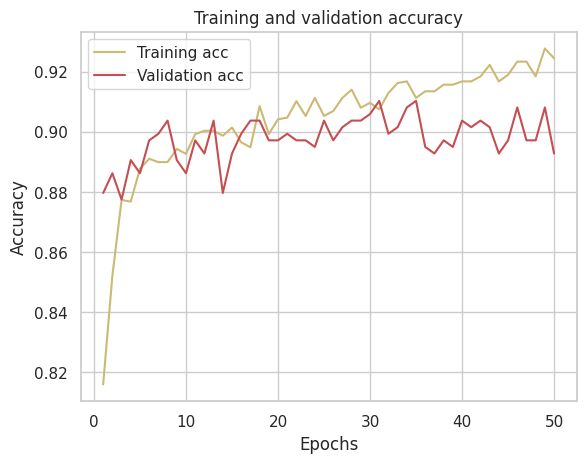

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       281
           1       0.90      0.88      0.89       290

    accuracy                           0.89       571
   macro avg       0.89      0.89      0.89       571
weighted avg       0.89      0.89      0.89       571

[[252  29]
 [ 35 255]]


In [41]:

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))